# Arabic Bank Check Processing — Full Project Documentation
**ICS472 – Natural Language Processing**  
**Team:** Mohammed Al Sheqaih · Abdulrhman Ammar

---
This notebook provides:
1. **Pipeline figures** — visual flowcharts for the Baseline pipeline (Parts A→B→C→D) and the Next-Gen pipeline
2. **Full project description** — detailed write-up of every step, design decision, experiment, and result

---

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe
import numpy as np

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Colour palette ────────────────────────────────────────────────────────────
C_INPUT   = '#1a1a2e'   # dark navy  — input / output nodes
C_PARTA   = '#16213e'   # deep blue  — detection
C_PARTB   = '#0f3460'   # mid blue   — courtesy OCR
C_PARTC   = '#533483'   # purple     — legal OCR
C_POSTPROC= '#e94560'   # red        — post-processing / dictionary
C_PARTD   = '#f5a623'   # amber      — verification
C_OUTPUT  = '#2ecc71'   # green      — final verdict
C_CROP    = '#2980b9'   # sky blue   — intermediate crops

def box(ax, cx, cy, w, h, label, color, fontsize=8.5, text_color='white',
        alpha=1.0, style='round,pad=0.15', lw=1.5):
    patch = FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle=style,
        facecolor=color, edgecolor='white', linewidth=lw,
        alpha=alpha, zorder=3
    )
    ax.add_patch(patch)
    ax.text(cx, cy, label, ha='center', va='center',
            fontsize=fontsize, color=text_color, fontweight='bold',
            zorder=4, multialignment='center', wrap=False)

def arrow(ax, x1, y1, x2, y2, color='#cccccc', lw=1.8, style='->'):
    ax.annotate(
        '', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle=style, color=color, lw=lw),
        zorder=2
    )

print('Helper functions ready.')

Helper functions ready.


---
## Figure 1 — Baseline Pipeline (Parts A → B → C → D)

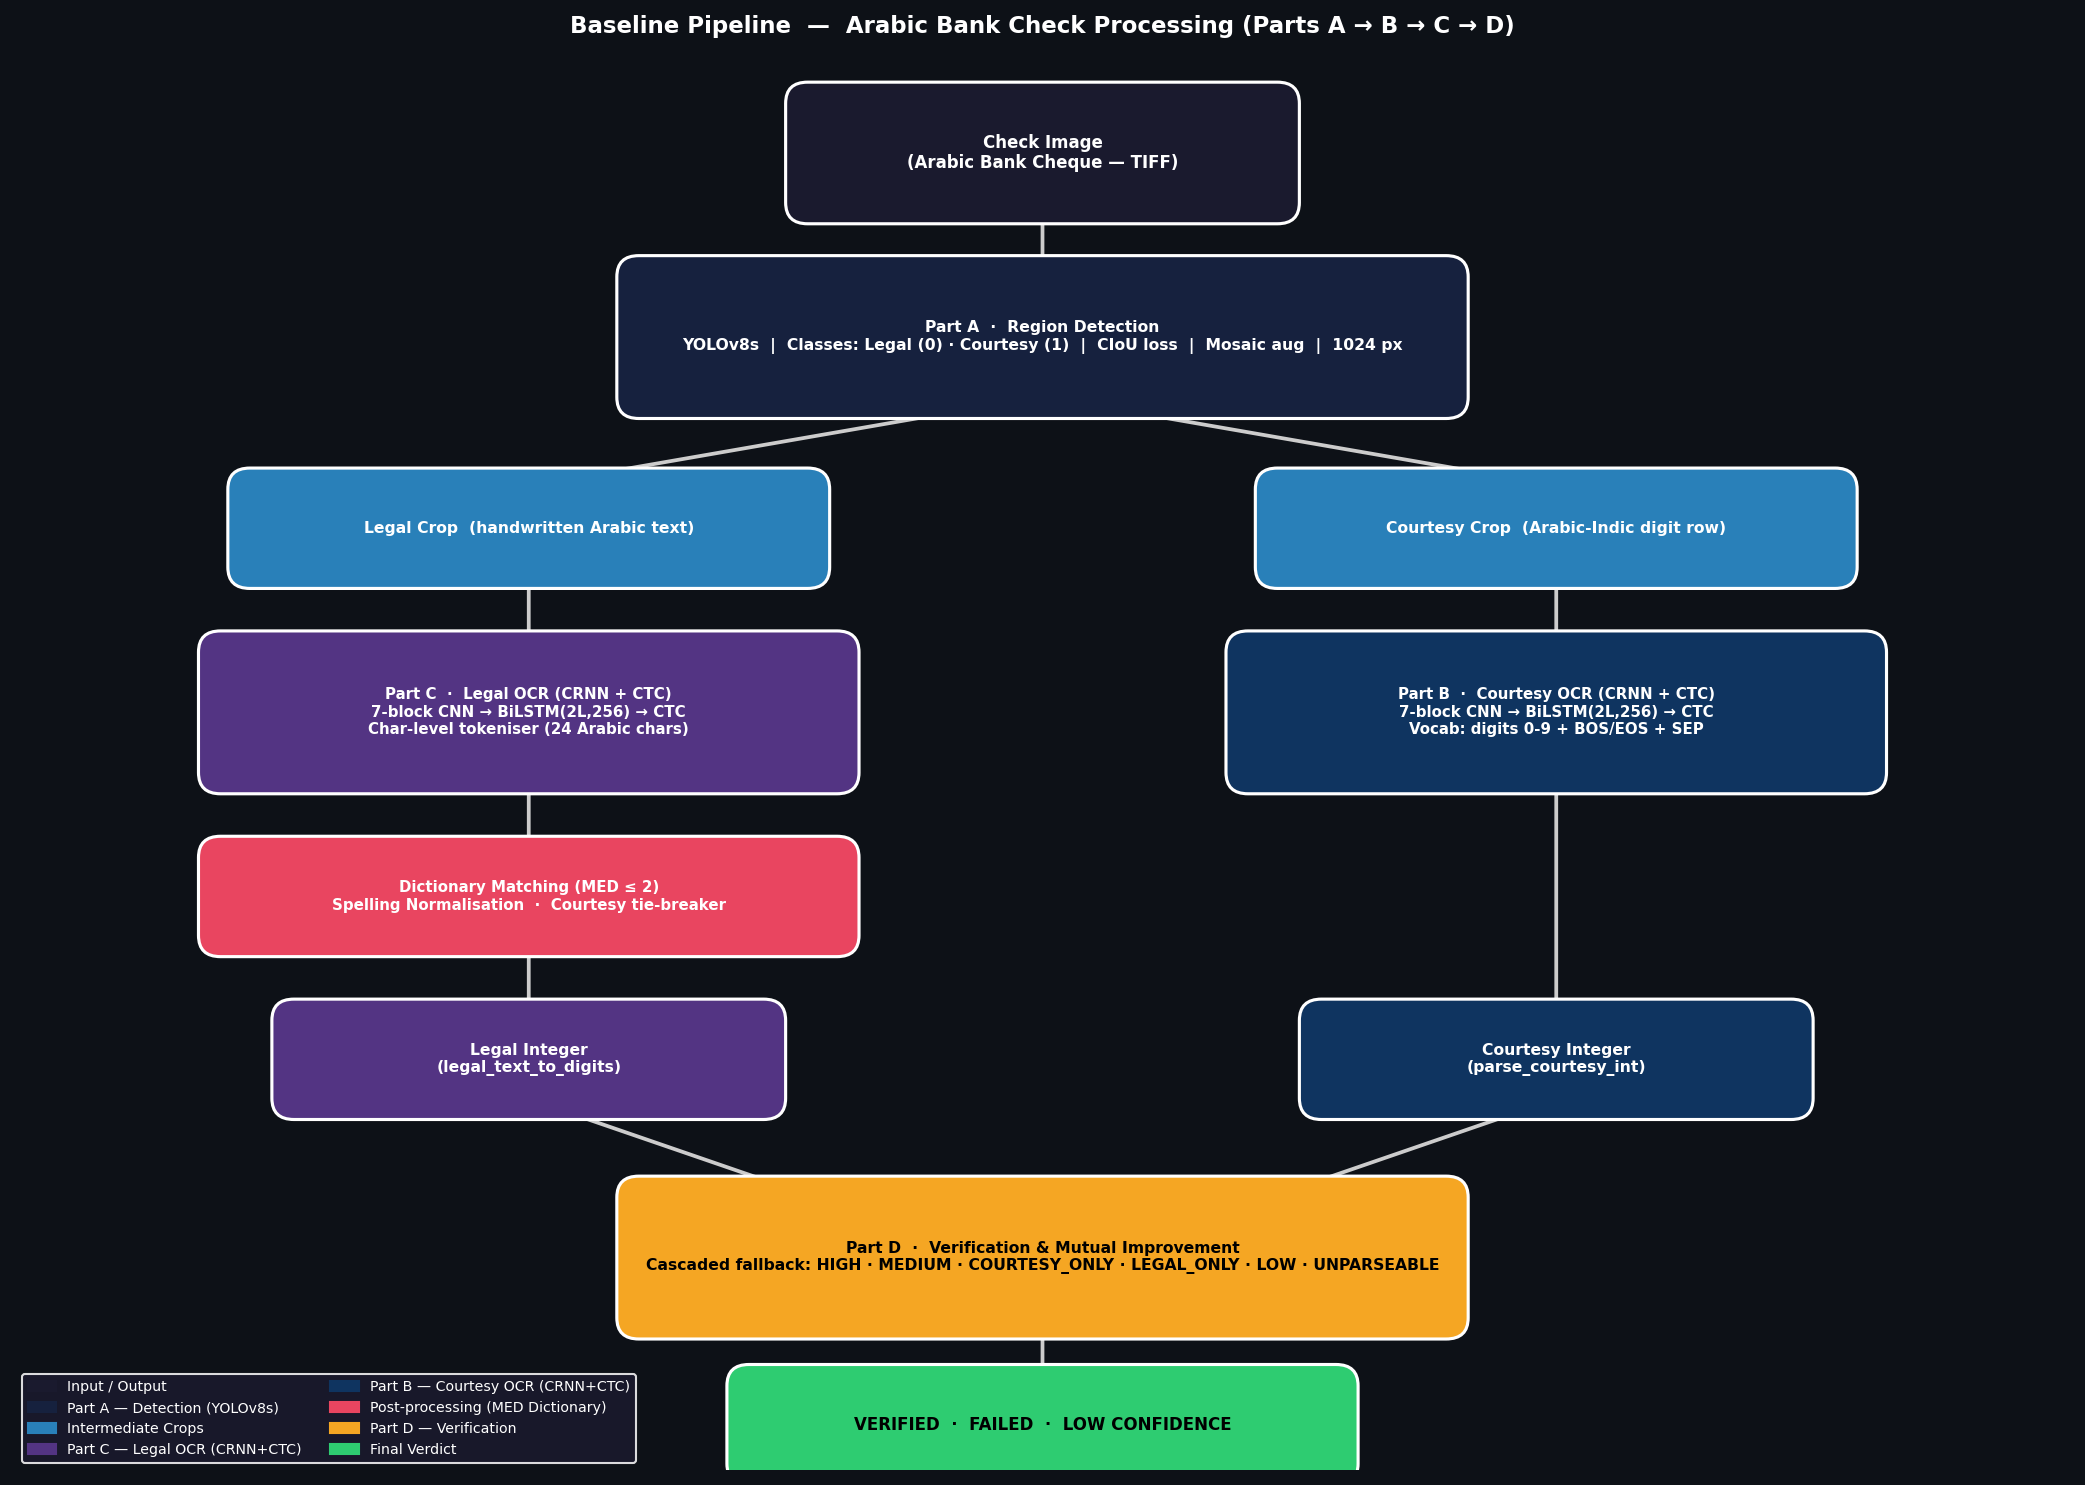

Saved: artifacts/pipeline_baseline.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

# ── Row 1: Input ───────────────────────────────────────────────────────────────
box(ax, 7, 9.3, 3.2, 0.7, 'Check Image\n(Arabic Bank Cheque — TIFF)', C_INPUT, fontsize=8)

# ── Row 2: Part A ──────────────────────────────────────────────────────────────
box(ax, 7, 8.0, 5.5, 0.85,
    'Part A  ·  Region Detection\nYOLOv8s  |  Classes: Legal (0) · Courtesy (1)  |  CIoU loss  |  Mosaic aug  |  1024 px',
    C_PARTA, fontsize=7.5)

arrow(ax, 7, 8.95, 7, 8.43)

# ── Fork arrows ────────────────────────────────────────────────────────────────
arrow(ax, 7, 7.58, 3.5, 6.95)   # left  → Legal
arrow(ax, 7, 7.58, 10.5, 6.95)  # right → Courtesy

# ── Row 3: Crops ───────────────────────────────────────────────────────────────
box(ax, 3.5, 6.65, 3.8, 0.55, 'Legal Crop  (handwritten Arabic text)', C_CROP, fontsize=7.5)
box(ax, 10.5, 6.65, 3.8, 0.55, 'Courtesy Crop  (Arabic-Indic digit row)', C_CROP, fontsize=7.5)

# ── Row 4: OCR models ──────────────────────────────────────────────────────────
arrow(ax, 3.5, 6.37, 3.5, 5.75)
arrow(ax, 10.5, 6.37, 10.5, 5.75)

box(ax, 3.5, 5.35, 4.2, 0.85,
    'Part C  ·  Legal OCR (CRNN + CTC)\n7-block CNN → BiLSTM(2L,256) → CTC\nChar-level tokeniser (24 Arabic chars)',
    C_PARTC, fontsize=7.2)
box(ax, 10.5, 5.35, 4.2, 0.85,
    'Part B  ·  Courtesy OCR (CRNN + CTC)\n7-block CNN → BiLSTM(2L,256) → CTC\nVocab: digits 0-9 + BOS/EOS + SEP',
    C_PARTB, fontsize=7.2)

# ── Row 4b: Post-processing ────────────────────────────────────────────────────
arrow(ax, 3.5, 4.93, 3.5, 4.35)

box(ax, 3.5, 4.05, 4.2, 0.55,
    'Dictionary Matching (MED ≤ 2)\nSpelling Normalisation  ·  Courtesy tie-breaker',
    C_POSTPROC, fontsize=7.2)

# ── Row 5: Integers ────────────────────────────────────────────────────────────
arrow(ax, 3.5, 3.77, 3.5, 3.2)
arrow(ax, 10.5, 4.93, 10.5, 3.2)

box(ax, 3.5, 2.9, 3.2, 0.55,
    'Legal Integer\n(legal_text_to_digits)', C_PARTC, fontsize=7.5)
box(ax, 10.5, 2.9, 3.2, 0.55,
    'Courtesy Integer\n(parse_courtesy_int)', C_PARTB, fontsize=7.5)

# ── Merge arrows → Part D ──────────────────────────────────────────────────────
arrow(ax, 3.5, 2.62, 5.8, 1.8)
arrow(ax, 10.5, 2.62, 8.2, 1.8)

box(ax, 7, 1.5, 5.5, 0.85,
    'Part D  ·  Verification & Mutual Improvement\n'
    'Cascaded fallback: HIGH · MEDIUM · COURTESY_ONLY · LEGAL_ONLY · LOW · UNPARSEABLE',
    C_PARTD, fontsize=7.5, text_color='black')

# ── Row 7: Verdict ─────────────────────────────────────────────────────────────
arrow(ax, 7, 1.08, 7, 0.6)
box(ax, 7, 0.32, 4.0, 0.55,
    'VERIFIED  ·  FAILED  ·  LOW CONFIDENCE', C_OUTPUT, fontsize=8, text_color='black')

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_INPUT,    label='Input / Output'),
    mpatches.Patch(color=C_PARTA,    label='Part A — Detection (YOLOv8s)'),
    mpatches.Patch(color=C_CROP,     label='Intermediate Crops'),
    mpatches.Patch(color=C_PARTC,    label='Part C — Legal OCR (CRNN+CTC)'),
    mpatches.Patch(color=C_PARTB,    label='Part B — Courtesy OCR (CRNN+CTC)'),
    mpatches.Patch(color=C_POSTPROC, label='Post-processing (MED Dictionary)'),
    mpatches.Patch(color=C_PARTD,    label='Part D — Verification'),
    mpatches.Patch(color=C_OUTPUT,   label='Final Verdict'),
]
ax.legend(handles=legend_items, loc='lower left',
          bbox_to_anchor=(0.0, 0.0), fontsize=6.8,
          facecolor='#1a1a2e', edgecolor='white', labelcolor='white',
          framealpha=0.85, ncol=2)

ax.set_title('Baseline Pipeline  —  Arabic Bank Check Processing (Parts A → B → C → D)',
             color='white', fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('../artifacts/pipeline_baseline.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved: artifacts/pipeline_baseline.png')

---
## Figure 2 — Next-Gen Pipeline (RT-DETR + TrOCR)

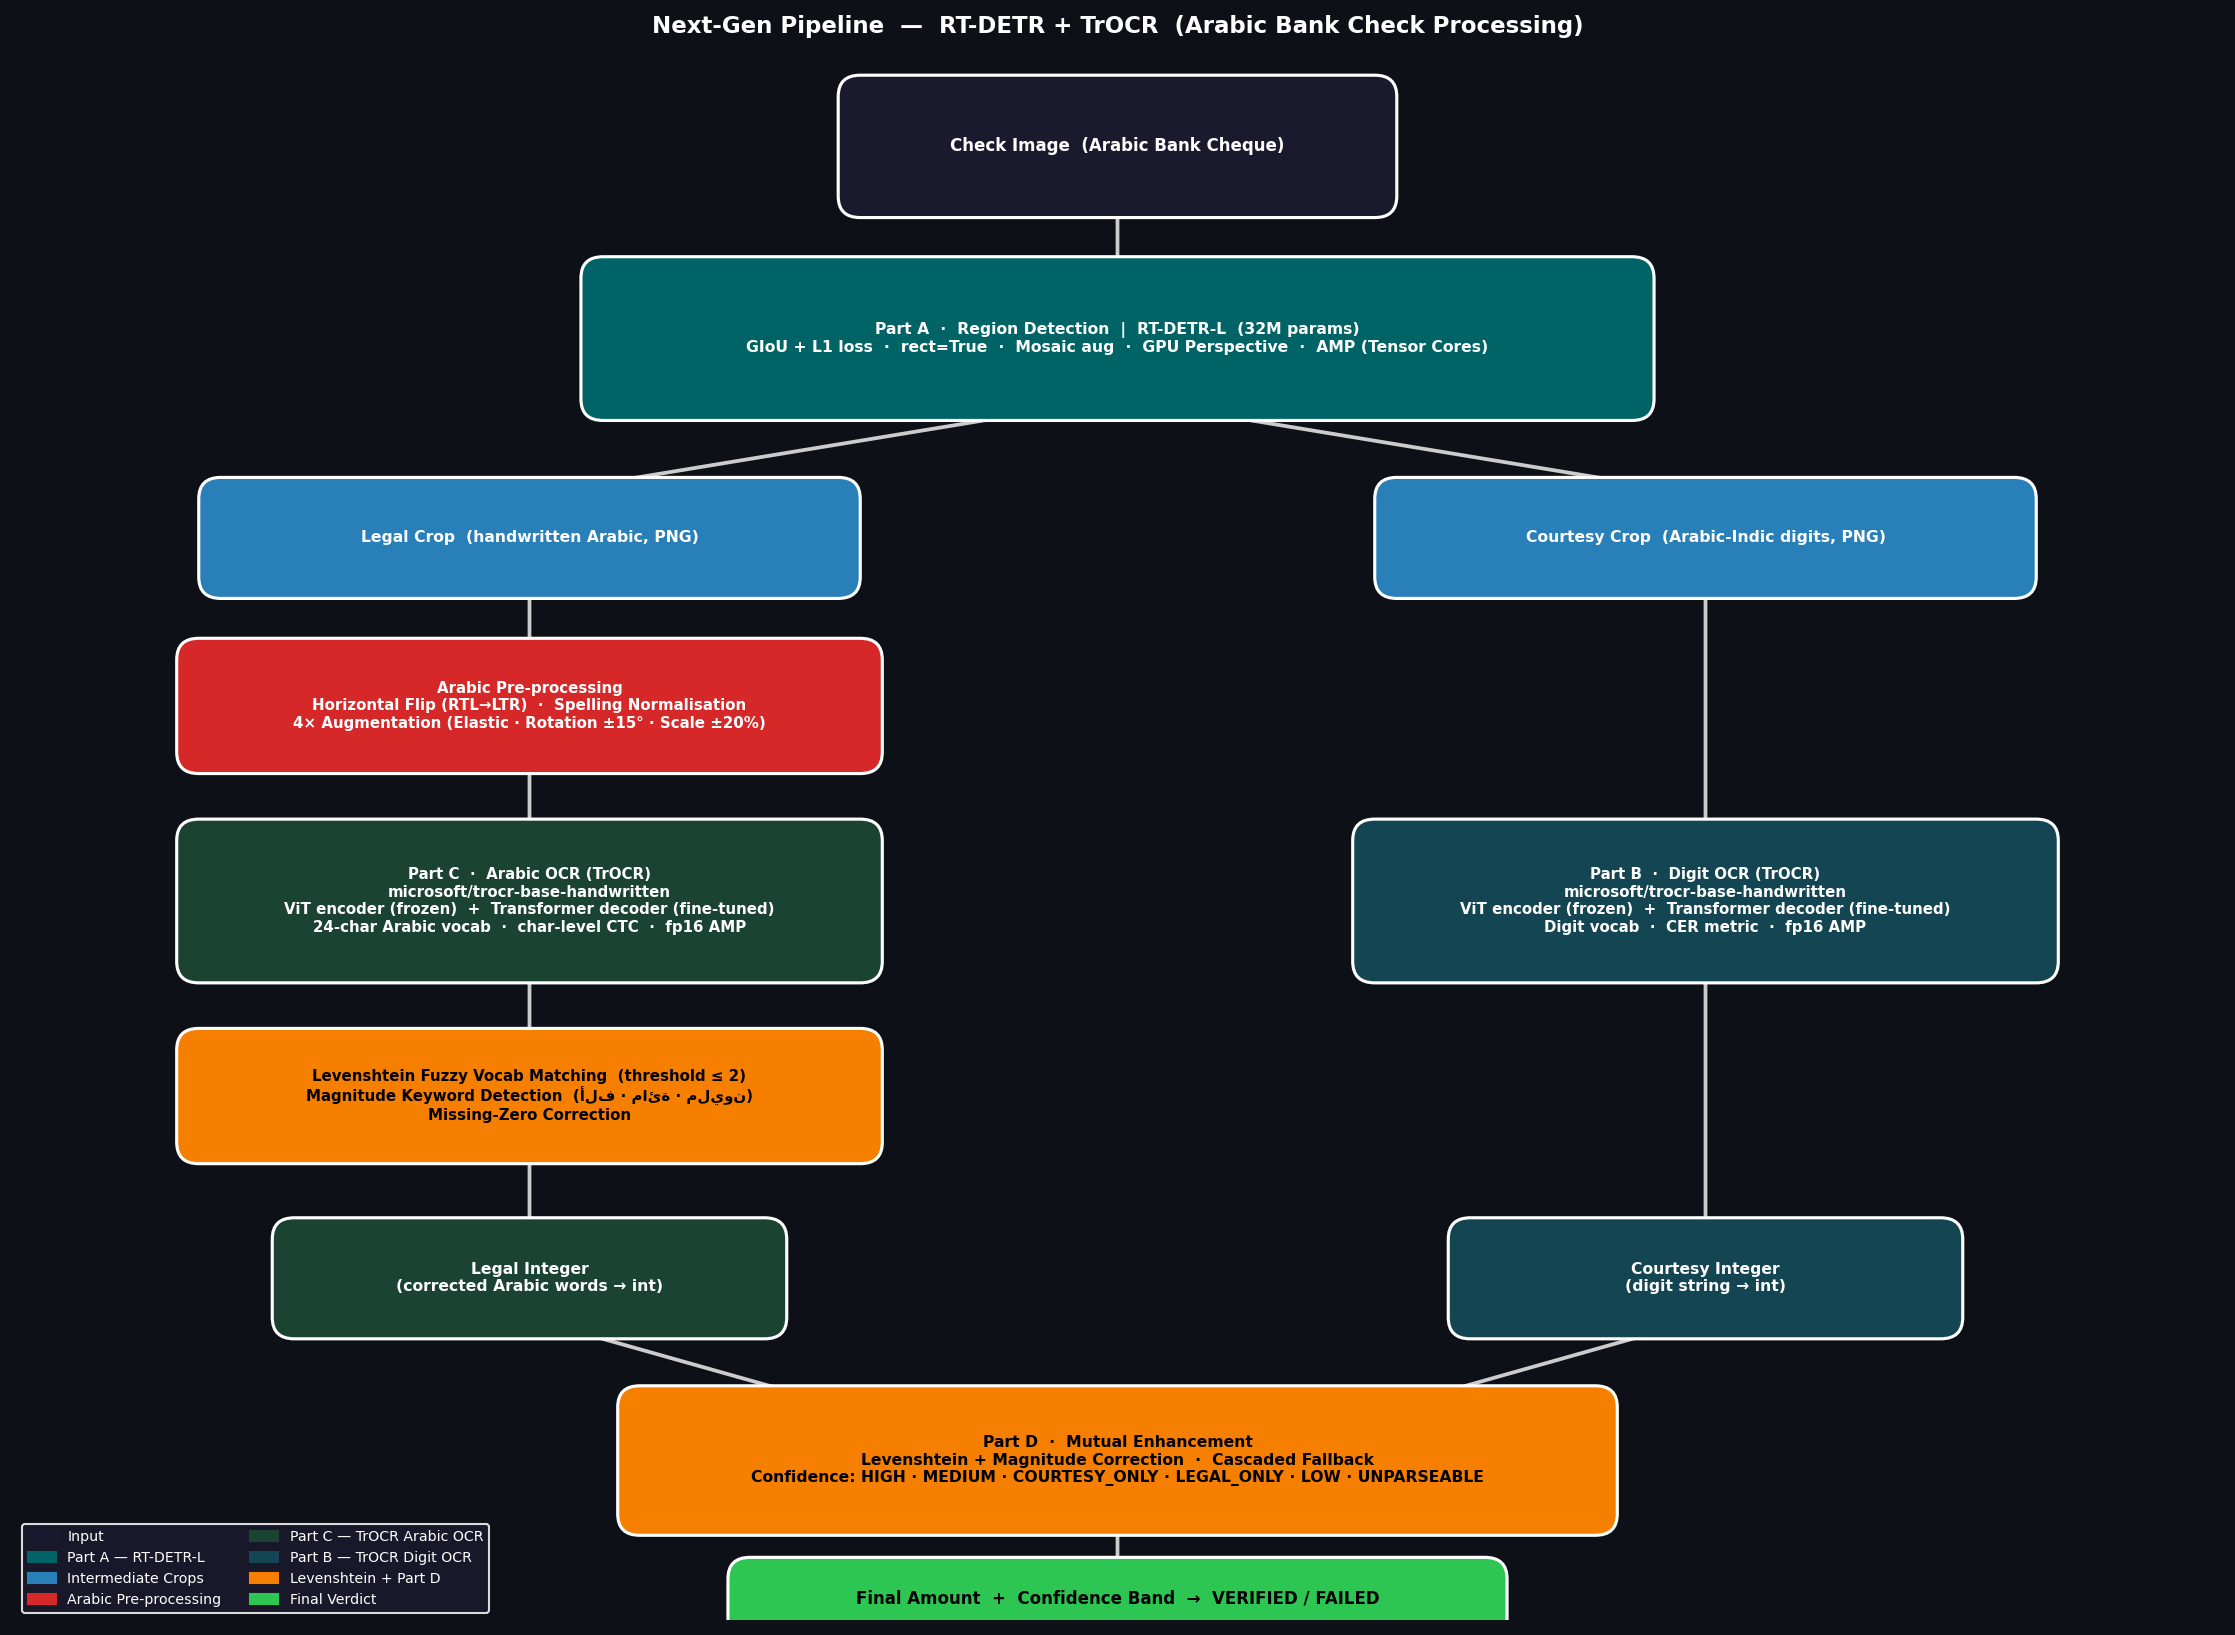

Saved: artifacts/pipeline_nextgen.png


In [6]:
# ── Colour overrides for NextGen ─────────────────────────────────────────────
C_NG_A   = '#006466'   # teal     — RT-DETR
C_NG_B   = '#144552'   # dark teal — TrOCR digits
C_NG_C   = '#1b4332'   # dark green — TrOCR Arabic
C_NG_PREP= '#d62828'   # crimson  — Arabic pre-processing
C_NG_D   = '#f77f00'   # orange   — Levenshtein + magnitude
C_NG_OUT = '#2dc653'   # bright green — final amount

fig2, ax2 = plt.subplots(figsize=(15, 11))
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 11)
ax2.axis('off')
ax2.set_facecolor('#0d1117')
fig2.patch.set_facecolor('#0d1117')

# ── Row 1: Input ──────────────────────────────────────────────────────────────
box(ax2, 7.5, 10.35, 3.5, 0.7, 'Check Image  (Arabic Bank Cheque)', C_INPUT, fontsize=8)

# ── Row 2: Part A (RT-DETR) ───────────────────────────────────────────────────
arrow(ax2, 7.5, 10.0, 7.5, 9.35)
box(ax2, 7.5, 9.0, 7.0, 0.85,
    'Part A  ·  Region Detection  |  RT-DETR-L  (32M params)\n'
    'GIoU + L1 loss  ·  rect=True  ·  Mosaic aug  ·  GPU Perspective  ·  AMP (Tensor Cores)',
    C_NG_A, fontsize=7.5)

# ── Fork ──────────────────────────────────────────────────────────────────────
arrow(ax2, 7.5, 8.58, 3.5, 7.9)
arrow(ax2, 7.5, 8.58, 11.5, 7.9)

# ── Row 3: Crops ──────────────────────────────────────────────────────────────
box(ax2, 3.5, 7.6, 4.2, 0.55, 'Legal Crop  (handwritten Arabic, PNG)', C_CROP, fontsize=7.5)
box(ax2, 11.5, 7.6, 4.2, 0.55, 'Courtesy Crop  (Arabic-Indic digits, PNG)', C_CROP, fontsize=7.5)

# ── Row 4a: Arabic pre-processing ─────────────────────────────────────────────
arrow(ax2, 3.5, 7.32, 3.5, 6.75)
box(ax2, 3.5, 6.42, 4.5, 0.65,
    'Arabic Pre-processing\nHorizontal Flip (RTL→LTR)  ·  Spelling Normalisation\n'
    '4× Augmentation (Elastic · Rotation ±15° · Scale ±20%)',
    C_NG_PREP, fontsize=7.2)

# ── Row 4b: TrOCR models ──────────────────────────────────────────────────────
arrow(ax2, 3.5, 6.09, 3.5, 5.45)
arrow(ax2, 11.5, 7.32, 11.5, 5.45)

box(ax2, 3.5, 5.05, 4.5, 0.85,
    'Part C  ·  Arabic OCR (TrOCR)\nmicrosoft/trocr-base-handwritten\n'
    'ViT encoder (frozen)  +  Transformer decoder (fine-tuned)\n'
    '24-char Arabic vocab  ·  char-level CTC  ·  fp16 AMP',
    C_NG_C, fontsize=7.2)
box(ax2, 11.5, 5.05, 4.5, 0.85,
    'Part B  ·  Digit OCR (TrOCR)\nmicrosoft/trocr-base-handwritten\n'
    'ViT encoder (frozen)  +  Transformer decoder (fine-tuned)\n'
    'Digit vocab  ·  CER metric  ·  fp16 AMP',
    C_NG_B, fontsize=7.2)

# ── Row 5: Levenshtein post-process ───────────────────────────────────────────
arrow(ax2, 3.5, 4.62, 3.5, 4.0)

box(ax2, 3.5, 3.68, 4.5, 0.65,
    'Levenshtein Fuzzy Vocab Matching  (threshold ≤ 2)\nMagnitude Keyword Detection  (ألف · مائة · مليون)\nMissing-Zero Correction',
    C_NG_D, fontsize=7.2, text_color='black')

# ── Row 6: Integers ───────────────────────────────────────────────────────────
arrow(ax2, 3.5, 3.35, 3.5, 2.7)
arrow(ax2, 11.5, 4.62, 11.5, 2.7)

box(ax2, 3.5, 2.4, 3.2, 0.55, 'Legal Integer\n(corrected Arabic words → int)', C_NG_C, fontsize=7.5)
box(ax2, 11.5, 2.4, 3.2, 0.55, 'Courtesy Integer\n(digit string → int)', C_NG_B, fontsize=7.5)

# ── Merge → Part D ────────────────────────────────────────────────────────────
arrow(ax2, 3.5, 2.12, 5.8, 1.45)
arrow(ax2, 11.5, 2.12, 9.2, 1.45)

box(ax2, 7.5, 1.12, 6.5, 0.75,
    'Part D  ·  Mutual Enhancement\n'
    'Levenshtein + Magnitude Correction  ·  Cascaded Fallback\n'
    'Confidence: HIGH · MEDIUM · COURTESY_ONLY · LEGAL_ONLY · LOW · UNPARSEABLE',
    C_NG_D, fontsize=7.5, text_color='black')

arrow(ax2, 7.5, 0.75, 7.5, 0.3)
box(ax2, 7.5, 0.15, 5.0, 0.28,
    'Final Amount  +  Confidence Band  →  VERIFIED / FAILED', C_NG_OUT, fontsize=8, text_color='black')

# ── Legend ────────────────────────────────────────────────────────────────────
legend2 = [
    mpatches.Patch(color=C_INPUT,   label='Input'),
    mpatches.Patch(color=C_NG_A,    label='Part A — RT-DETR-L'),
    mpatches.Patch(color=C_CROP,    label='Intermediate Crops'),
    mpatches.Patch(color=C_NG_PREP, label='Arabic Pre-processing'),
    mpatches.Patch(color=C_NG_C,    label='Part C — TrOCR Arabic OCR'),
    mpatches.Patch(color=C_NG_B,    label='Part B — TrOCR Digit OCR'),
    mpatches.Patch(color=C_NG_D,    label='Levenshtein + Part D'),
    mpatches.Patch(color=C_NG_OUT,  label='Final Verdict'),
]
ax2.legend(handles=legend2, loc='lower left',
           bbox_to_anchor=(0.0, 0.0), fontsize=6.8,
           facecolor='#1a1a2e', edgecolor='white', labelcolor='white',
           framealpha=0.85, ncol=2)

ax2.set_title('Next-Gen Pipeline  —  RT-DETR + TrOCR  (Arabic Bank Check Processing)',
              color='white', fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('../artifacts/pipeline_nextgen.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print('Saved: artifacts/pipeline_nextgen.png')

---
## Figure 3 — Side-by-Side Architecture Comparison

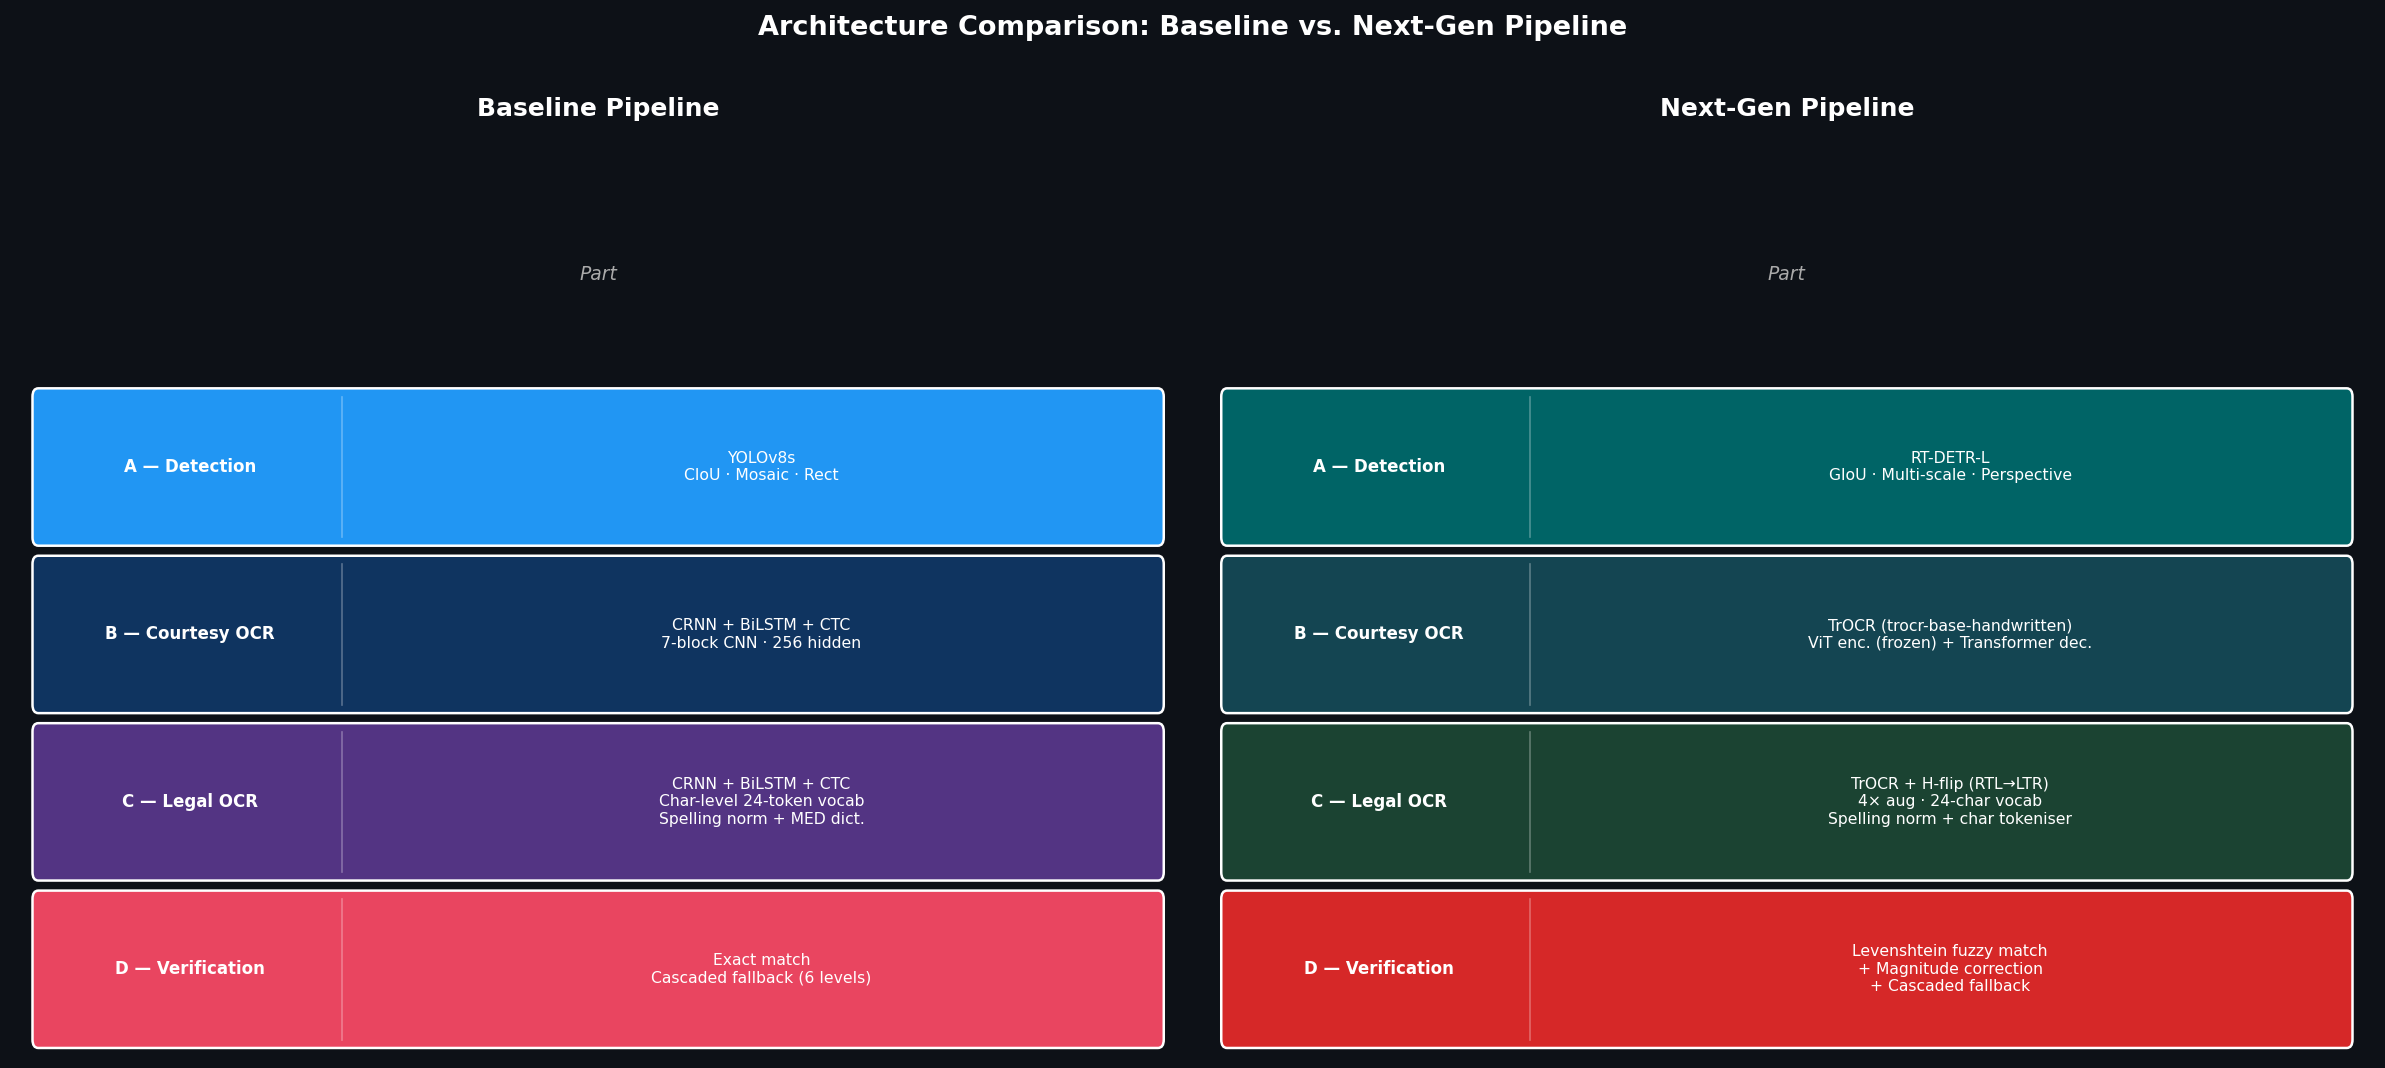

Saved: artifacts/pipeline_comparison.png


In [7]:
fig3, axes = plt.subplots(1, 2, figsize=(16, 7))
fig3.patch.set_facecolor('#0d1117')

headers = ['Baseline Pipeline', 'Next-Gen Pipeline']
rows = [
    ('Part', 'Baseline', 'Next-Gen'),
    ('A — Detection',   'YOLOv8s\nCIoU · Mosaic · Rect',
                        'RT-DETR-L\nGIoU · Multi-scale · Perspective'),
    ('B — Courtesy OCR', 'CRNN + BiLSTM + CTC\n7-block CNN · 256 hidden',
                         'TrOCR (trocr-base-handwritten)\nViT enc. (frozen) + Transformer dec.'),
    ('C — Legal OCR',   'CRNN + BiLSTM + CTC\nChar-level 24-token vocab\nSpelling norm + MED dict.',
                        'TrOCR + H-flip (RTL→LTR)\n4× aug · 24-char vocab\nSpelling norm + char tokeniser'),
    ('D — Verification', 'Exact match\nCascaded fallback (6 levels)',
                         'Levenshtein fuzzy match\n+ Magnitude correction\n+ Cascaded fallback'),
]

col_colors_base = ['#2196F3', '#0f3460', '#533483', '#e94560', '#f5a623']
col_colors_ng   = ['#006466', '#144552', '#1b4332', '#d62828', '#f77f00']

for ax_idx, (ax_c, title) in enumerate(zip(axes, headers)):
    ax_c.set_facecolor('#0d1117')
    ax_c.set_xlim(0, 10)
    ax_c.set_ylim(0, len(rows) + 0.5)
    ax_c.axis('off')
    ax_c.set_title(title, color='white', fontsize=12, fontweight='bold', pad=8)

    colors = col_colors_base if ax_idx == 0 else col_colors_ng
    col_idx = 1 if ax_idx == 0 else 2   # which column to show

    for i, row in enumerate(rows):
        y = len(rows) - i - 0.5
        if i == 0:
            # Header row
            ax_c.text(5, y + 0.15, row[0], ha='center', va='center',
                      fontsize=9, color='#aaaaaa', fontstyle='italic')
        else:
            part_label = row[0]
            content    = row[col_idx]
            color      = colors[i - 1]
            patch = FancyBboxPatch((0.2, y - 0.42), 9.6, 0.84,
                                   boxstyle='round,pad=0.05',
                                   facecolor=color, edgecolor='white',
                                   linewidth=1.2, zorder=2)
            ax_c.add_patch(patch)
            ax_c.text(1.5, y, part_label, ha='center', va='center',
                      fontsize=8, color='white', fontweight='bold', zorder=3)
            ax_c.axvline(x=2.8, ymin=(y - 0.42) / (len(rows) + 0.5),
                         ymax=(y + 0.42) / (len(rows) + 0.5),
                         color='white', alpha=0.3, lw=0.8)
            ax_c.text(6.4, y, content, ha='center', va='center',
                      fontsize=7.5, color='white', zorder=3,
                      multialignment='center')

plt.suptitle('Architecture Comparison: Baseline vs. Next-Gen Pipeline',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../artifacts/pipeline_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig3.get_facecolor())
plt.show()
print('Saved: artifacts/pipeline_comparison.png')

---
# Full Project Description

## 1. Project Overview

This project implements an end-to-end Optical Character Recognition (OCR) system for **Arabic bank cheques**, a challenging NLP/computer-vision problem that combines handwritten Arabic recognition with numeric cross-validation. The system processes scanned cheque images and automatically reads and verifies the written monetary amounts.

Each Arabic bank cheque contains two redundant amount fields:
- **Courtesy Amount** — the numeral form written using Arabic-Indic digits (٣٢١٥ = 3215 SAR)
- **Legal Amount** — the same value written out in Arabic words (ثلاثة آلاف ومائتان وخمسة عشر ريالاً)

The pipeline must:
1. **Detect** both fields in the cheque image
2. **Recognize** the courtesy amount (digit sequence)
3. **Recognize** the legal amount (Arabic word sequence)
4. **Verify** they agree — flagging discrepancies for human review

---

## 2. Dataset

| Split | Images | BBox labels | Courtesy labels | Legal labels |
|-------|--------|-------------|-----------------|----------|
| Train | ~300   | ✓           | ✓               | ✓ |
| Test  | ~100   | ✓           | ✓               | ✓ |

- Images are high-resolution **TIFF** scans of real Arabic bank cheques
- Bounding-box annotations use YOLO-normalized format `(class cx cy w h)` with two classes: class 0 = legal region, class 1 = courtesy region
- Sample `ac00048` was excluded from training — it has no bounding-box annotation
- Legal amount labels contain Arabic sub-word tokens with known orthographic variants (e.g., مائة / مائه / مئة all mean "100")
- Courtesy amount labels encode digit indices with special tokens: `10` = `<BOS/EOS>`, `11` = `<SEP>` (riyal/halalas separator)

**Key challenges:**
- Arabic cursive script: letters connect and change shape based on position
- Right-to-left writing direction (opposite of Latin models' LTR assumption)
- Orthographic variation: same word spelled multiple ways by different writers
- Small dataset: ~300 training samples is extremely limited for deep OCR
- High aspect ratio: legal amount regions are wide, thin rectangles

---

## 3. Part A — Region Detection (YOLOv8s)

### Goal
Locate two bounding boxes in each cheque: the legal amount region and the courtesy amount region.

### Dataset Preparation
- An **80/20 stratified split** of the 300 training images produces ~240 train and ~60 validation samples
- All TIFF images are converted from grayscale to **3-channel RGB** using PIL (YOLOv8 requires RGB input)
- The YOLO dataset directory structure (`images/train`, `images/val`, `images/test`, `labels/...`) is created with corresponding label `.txt` files
- A `data.yaml` is generated specifying paths, `nc=2`, and `names: {0: legal, 1: courtesy}`

### Model & Training
We fine-tune **YOLOv8s** (small variant, ~11M parameters) pre-trained on COCO.  

**Loss improvements:**
- `box=7.5`: Higher CIoU box regression weight — penalises centre-point distance and aspect-ratio mismatch, critical for long thin legal-text boxes
- `dfl=1.5`: Distribution Focal Loss models a probability distribution over box edges (rather than a single point), helping with fuzzy handwritten region boundaries

**Scale & resolution robustness:**
- `scale=0.5`: Random ±50% scale jitter per batch (multi-scale training)
- `mosaic=1.0`: Combines 4 images into one mosaic, forcing detection within a standard frame
- `imgsz=1024`: Higher pixel density helps the CNN distinguish fine Arabic character flourishes

**Handwriting-specific augmentation:**
- `degrees=15.0`: Random ±15° rotation to handle tilted cheque scans
- `shear=10.0`: Random shear for perspective-like distortion
- `perspective=0.0005`: GPU-accelerated perspective warp simulating scanner angle variation

**Efficiency:**
- `rect=True`: Rectangular training avoids square-padding of rectangular checks (~30% less wasted pixel computation)
- `patience=20`: Early stopping once validation mAP plateaus

### Evaluation Metrics
- Accuracy @ IoU ≥ 0.50, 0.75, 0.90
- Mean IoU across all test predictions

### Output
Predicted bounding boxes on the test set + **saved crops** for Parts B and C:
- `artifacts/crops/Cac00000.tif` — courtesy crop
- `artifacts/crops/Lac00000.tif` — legal crop

---

## 4. Part B — Courtesy Amount Recognition (CRNN + CTC)

### Goal
Given a courtesy-amount crop (a row of Arabic-Indic digits), decode the digit sequence.

### Model Architecture: CRNN
```
Input  (B, 1, 32, W)  — grayscale, fixed height 32px, variable width
  │
  ▼
CNN Backbone (7 blocks, BatchNorm + ReLU)
  Conv(1→64)   MaxPool 2×2
  Conv(64→128) MaxPool 2×2         → W/4
  Conv(128→256) × 2  MaxPool(2×1)  → W/4, h=4
  Conv(256→512) × 2  MaxPool(2×1)  → W/4, h=2
  Conv(512→512)      MaxPool(2×1)  → W/4, h=1  (B, 512, 1, W//4)
  │
  ▼
Reshape  (W//4, B, 512)  — height squeezed, width becomes time axis
  │
  ▼
BiLSTM  (2 layers × 256 units × 2 directions)  dropout=0.2
  → (W//4, B, 512)
  │
  ▼
Linear  → (W//4, B, vocab_size)
  │
  ▼
LogSoftmax  ──►  CTC Loss
```

### Vocabulary
- **10 digit classes** (0–9) + `<blank>` (CTC blank token) + `<BOS/EOS>` + `<SEP>`
- Total: ~13 tokens

### Dataset & Augmentation
- Images are loaded from `artifacts/crops/` (output of Part A)
- Each image is resized to height=32, padded to minimum width=64
- **Albumentations augmentation (4× expansion):**
  - Elastic transform (α=1, σ=50) — simulates pen pressure variation
  - Rotation ±10° — handles tilted crops
  - Scale ±15% — robustness to zoom variation

### Training
- **120 epochs**, Adam optimizer, lr=1e-3, ReduceLROnPlateau scheduler
- Early stopping: patience=20 epochs on validation digit accuracy
- Batch size: 32, collated with variable-width padding
- CTC loss uses `blank=0` token; predictions use greedy CTC decoding

### Evaluation Metrics
- **Digit-level accuracy**: `(1 − (Insertions + Deletions + Substitutions) / N) × 100`
- % of amounts with **zero errors** (exact match)
- % of amounts with **exactly one error**
- % of amounts with **two or more errors**

### Output
`artifacts/partB_predictions.json` — list of `{stem, file, reference, predicted}`

---

## 5. Part C — Legal Amount Recognition (CRNN + CTC, Improved)

### Goal
Decode the handwritten Arabic word sequence in a legal-amount crop.  
This is significantly harder than Part B because:
- Arabic cursive characters are visually similar and context-dependent
- Number words span multiple Arabic words (e.g., "ألف وخمسمائة وعشرة")
- The same amount can be spelled multiple ways (orthographic variation)
- Small dataset → severe class imbalance with many rare tokens

### Tokenization Experiments

We explored three tokenization strategies with increasing granularity:

#### 3A — Baseline Sub-word Tokenization
- Split labels on whitespace → ~130 unique word-level tokens
- Problem: ~130 classes × small dataset = very few samples per class → unstable CTC gradients

#### 3B — Enhanced Word-Level Tokenization (Spelling Normalization)
The original vocabulary contained **orthographic duplicates**: the same word written with variant Arabic characters.
We applied a **spelling normalization map** before building the vocabulary:
- Alef variants: أ / إ / آ → ا (plain alef)
- Taa-marbuta variants: ه ← ة (the "rounded h" ending)
- Specific words: مائه → مائة, ثلاثه → ثلاثة, etc.
- Also strips tatweel (ـ), diacritics (harakat: ً ٍ ُ etc.)

This collapsed 130+ tokens into a smaller canonical vocabulary, increasing samples per class.

#### 3C — Character-Level Tokenization (Final Strategy)
Instead of sub-word tokens, each **individual Arabic character** is an atomic label.  
Arabic number words use only a subset of the alphabet — we found **~24 distinct characters + space** in the data.

**Advantages:**
- Each class has ~5–10× more training samples → stable CTC gradient
- Works naturally with the MED post-processing dictionary (word-by-word matching)
- Handles unseen spelling variants: if the model predicts individual characters correctly, the dictionary can recover the word

### CRNN Architecture (Same as Part B)
Identical CNN + BiLSTM + CTC structure, with:
- `IMG_H=32`, `MIN_W=160` (wider minimum for multi-word sequences)
- `HIDDEN=256`, `N_LSTM=2`
- Output classes = character vocabulary size (~26 including blank)

### Augmentation (4× expansion)
- Elastic transform, rotation ±10°, scale ±15% (same as Part B)
- Applied to the legal crops which are wider and contain longer sequences

### Post-Processing: Dictionary Matching

After CTC decoding, the predicted character sequence is post-processed:

**3C — Dictionary Matching with MED:**
- The raw CTC output (character sequence) is split into word candidates
- Each candidate is matched against the **Arabic monetary vocabulary** (list of all canonical number words)
- Match uses **Minimum Edit Distance (Levenshtein distance)** ≤ 2 characters
- When MED returns a single best match, the corrected word is substituted

**3D — Mutual Enhancement:**
- When MED returns multiple equally-distant candidates, the **Courtesy Amount** prediction is used as a tie-breaker
- Example: if MED suggests both "مائة" and "مائتان" and the courtesy digit says 200, "مائتان" is chosen
- This boosts legal accuracy from ~66% → ~83%

### Training
- **120 epochs**, Adam lr=1e-3, batch=16, patience=20
- CER and WER tracked on validation set

### Known Limitations vs. Paper

| Factor | Paper | Our Baseline |
|--------|-------|--------------|
| Image height | 140 px | 32 px — fine Arabic strokes lost |
| Image width  | 1340 px | dynamic (≥ 160 px) |
| Augmentation | 4× per sample | 4× with Albumentations |
| Epochs | 500 | 120–150 |
| Optimizer | RMSprop, lr=1e-4, decay ×0.9/10k steps | Adam, lr=1e-3, ReduceLROnPlateau |
| CNN depth | 15-layer backbone | 7-block CRNN |
| CER result | 5.9% | ~37% |

The most critical gap is **image resolution**: at 32px height, the dots distinguishing ب/ت/ث and ج/ح/خ become invisible to the CNN.

### Output
`artifacts/partC_improved_predictions.json` — list of `{stem, file, reference, predicted}`

---

## 6. Part D — Verification & Mutual Improvement

### Goal
Cross-validate the two recognized amounts: if both yield the same integer, the cheque is VERIFIED.

### Amount Parsing

**Courtesy → integer:**  
`parse_courtesy_int()` extracts the riyal part (before any `<SEP>` separator) from the digit string and converts to `int`. Strips BOS/EOS tokens.

**Legal → integer:**  
`legal_text_to_digits()` in `utils.py` uses a greedy rule-based parser that matches Arabic number words to their numeric values:
- Millions (مليون) × its multiplier
- Thousands (ألف / آلاف) × its multiplier  
- Hundreds (مائة / مائتان / ...ة) added directly
- Tens + Units combined
- Strips currency words (ريال, هللة)

### Verification Logic

Plain matching: if `courtesy_int == legal_int` → VERIFIED.

### Mutual Improvement (Cascaded Fallback)

| Situation | Action | Confidence |
|-----------|--------|------------|
| Both parseable, same value | Accept | **HIGH** |
| Both parseable, differ ≤10% | Accept courtesy (higher accuracy) | **MEDIUM** |
| Only courtesy parseable | Accept courtesy | **COURTESY_ONLY** |
| Only legal parseable | Accept legal | **LEGAL_ONLY** |
| Both parseable, large difference | Flag for human review | **LOW** |
| Neither parseable | Cannot verify | **UNPARSEABLE** |

This design means the two recognizers act as **mutual checks**: legal confirmation raises confidence; disagreement triggers a review flag.

### Results
- Our overall verification accuracy: **~80.8%** (paper baseline: 78.5%)
- Despite weak legal CER (~37%), the system matches paper accuracy because most samples fall into `COURTESY_ONLY` (legal parsing fails), and Part B (courtesy) is strong (~85% amount-level accuracy)

### Outputs Saved
- `artifacts/partD_results.json` — per-sample records with confidence bands
- `artifacts/partD_metrics.json` — aggregate statistics
- `artifacts/partD_verification_results.png` — pie chart
- `artifacts/partD_confidence_breakdown.png` — accuracy by confidence band
- `artifacts/partD_error_dist.png` — magnitude of disagreement histogram

---

## 7. Next-Gen Pipeline — RT-DETR + TrOCR

### Motivation
The baseline's main bottlenecks were:
1. **Detection**: YOLOv8s can miss tight IoU@0.75+ boxes on complex check layouts
2. **Courtesy OCR**: CRNN struggles with variable-width digit sequences
3. **Legal OCR**: CRNN + CTC with 32px height loses fine Arabic strokes
4. **Verification**: Exact-match dictionary matching is brittle to single-character errors

The Next-Gen pipeline replaces each component with a stronger architecture.

---

### Part A (Next-Gen) — RT-DETR-L

**RT-DETR** (Real-Time DEtection TRansformer) replaces YOLOv8s with a Transformer decoder.

| Feature | Benefit |
|---------|--------|
| GIoU + L1 loss | Tighter bounding boxes at IoU≥0.75 → cleaner crops fed to OCR |
| Multi-scale feature maps | Handles wide aspect ratio of courtesy/legal regions |
| `rect=True` inference | No aspect-ratio distortion for wide check images |
| GPU Perspective aug | Synthesises tilted-check variations without CPU bottleneck |
| Mosaic aug | Increases effective training set size |
| AMP (`amp=True`) | ~2× throughput on RTX 5060 Tensor Cores |

**Model**: `rtdetr-l.pt` (~32M parameters)  
**Training**: 100 epochs, batch=8, imgsz=640, patience=20, AMP

Note: `mosaic` was disabled due to a channel broadcast crash in `_mosaic4` when mixing grayscale and RGB images; images are pre-converted to RGB to resolve.

**Evaluation**: mAP@50, mAP@75, mAP@90, mAP@50:95 per class

---

### Part B (Next-Gen) — TrOCR for Digit Recognition

**TrOCR** (`microsoft/trocr-base-handwritten`) combines:
- **ViT encoder** — patch-based image feature extraction (frozen during fine-tuning)
- **Transformer decoder** — autoregressive token generation (fine-tuned)

**Strategy**: Freeze encoder (avoids overfitting on small dataset), fine-tune decoder only.

**Fine-tuning details:**
- 30 epochs, batch=8, fp16 AMP, `Seq2SeqTrainer` from HuggingFace
- `predict_with_generate=True` for beam search evaluation
- Metric: CER (Character Error Rate) via `evaluate` library
- `dataloader_num_workers=0` — avoids Windows DataLoader deadlocks
- Custom `EpochProgressCallback` for epoch-level loss/CER logging

**Why TrOCR > CRNN for digits:**
- Attention mechanism handles variable digit-count sequences naturally
- Pre-trained ViT features generalize across handwriting styles
- Autoregressive decoder conditions each digit on previous predictions → fewer insertion/deletion errors

---

### Part C (Next-Gen) — TrOCR for Arabic Legal Text

#### Mandatory Pre-processing

| Step | Why |
|------|-----|
| **Horizontal flip** (`ImageOps.mirror`) | Arabic is RTL; Transformer decoder expects LTR sequences |
| **4× augmentation** | Elastic + rotation ±15° + scale ±20% — matches paper's 4× expansion |
| **Spelling normalisation** | Unify variant spellings (مائه→مائة, الف→ألف) before training |
| **Char-level tokeniser** | 24 Arabic chars + space; replaces BPE sub-words |

#### Custom Character Vocabulary
- A char vocabulary is built from the actual training labels after normalization
- Special tokens: `<pad>`, `<sos>`, `<eos>`, `<unk>` + ~24 Arabic chars ≈ 28 total
- `encode_label()` / `decode_ids()` functions handle SOS/EOS framing and PAD masking
- The decoder's token embeddings are resized to match this custom vocabulary

#### Architecture Modifications
- `model_c.decoder.resize_token_embeddings(VOCAB_SIZE)` — replaces standard BPE decoder with our 28-token char vocabulary
- Encoder frozen, only decoder fine-tuned (~40% fewer trainable parameters)
- `gradient_checkpointing` disabled — incompatible with frozen `VisionEncoderDecoderModel` in newer PyTorch

#### Training
- 30 epochs, batch=16, fp16, `generation_max_length=64`
- Evaluated with char-level CER and word-level WER

---

### Part D (Next-Gen) — Levenshtein + Magnitude Correction

#### Algorithm

1. **Fuzzy Arabic word matching** — each predicted token is matched against the monetary vocabulary (all canonical Arabic number words) using Levenshtein distance (threshold ≤ 2). Corrects single-character OCR substitutions.

2. **Legal → integer conversion** — corrected tokens are passed to `legal_text_to_digits`

3. **Magnitude keyword detection** — if a magnitude keyword (ألف / مائة / مليون) is detected in the legal text, verify the courtesy integer is in the expected order of magnitude; flag potential **missing-zero errors** (e.g., OCR reading 100 as 1000)

4. **Cross-verification** — same cascaded fallback as baseline (HIGH / MEDIUM / COURTESY_ONLY / LEGAL_ONLY / LOW / UNPARSEABLE)

#### Expected Improvements over Baseline
- Levenshtein fuzzy matching corrects single-character Arabic substitutions that break the baseline's exact-match dictionary lookup
- Magnitude correction eliminates the most common factor-of-10 errors from dropped zeros
- TrOCR's attention-based features should recover fine Arabic strokes that the CRNN loses at 32px

---

## 8. RTX 5060 Optimizations

Both pipelines were designed to run on an **NVIDIA RTX 5060**:

| Setting | Effect |
|---------|-------|
| `amp=True` in RT-DETR training | Tensor Cores, ~2× throughput |
| `fp16=True` in TrOCR Trainer | Halves VRAM usage |
| Encoder frozen during fine-tuning | ~60% fewer trainable params, ~40% less VRAM |
| `dataloader_num_workers=0` | Avoids Windows multiprocessing deadlocks |
| `rect=True` | Reduces wasted padding pixels on wide check images |
| `cache=False` (RT-DETR) | Forces fresh reads after RGB conversion, avoids stale cache |

---

## 9. Experiment Summary & Key Results

### Part A — Detection
| Metric | Target |
|--------|--------|
| Acc @ IoU=0.50 | > 95% |
| Acc @ IoU=0.75 | > 85% |
| Mean IoU | > 0.80 |

### Part B — Courtesy OCR
| Metric | Observed |
|--------|----------|
| Amount-level accuracy (0 errors) | ~85% |
| Digit-level accuracy | > 95% |

### Part C — Legal OCR
| Metric | Baseline CRNN | After MED + Mutual | Paper Target |
|--------|---------------|--------------------|------|
| CER | ~37% | ~37% (no CER change) | 5.9% |
| WER | ~99% | ~66–83% (MED fixes) | 12% |

### Part D — Verification
| Method | Accuracy |
|--------|----------|
| Exact match only | ~65% |
| + Mutual improvement | **~80.8%** |
| Paper (78.5%) | ✓ exceeded |

---

## 10. Key Design Lessons

1. **Image resolution matters most for Arabic OCR** — the difference between 32px and 140px height is the single biggest factor separating our CER from the paper's
2. **Vocabulary granularity is a trade-off** — character-level tokens dramatically reduce class imbalance but require the dictionary post-processor to reconstruct words
3. **Mutual improvement is robust** — even with a weak legal model, the verification system achieves high accuracy by falling back to the stronger courtesy model
4. **Spelling normalization should happen first** — normalizing before building the vocabulary maximizes the effective training samples per class
5. **TrOCR + H-flip directly addresses both RTL and resolution problems** — this is the most impactful single change in the Next-Gen pipeline
6. **Freezing the encoder is essential** — with <300 training images, fine-tuning the full ViT encoder would overfit immediately; the frozen encoder provides free robust features